# Notebook 00 · Sentinel-2 2018 Extraction for the Milan IMD Baseline

Builds the **baseline predictor table** for comparison against the 64-dim
Google Satellite Embedding run (`01_IMD_Prediction_Milan_blockCV_v2.ipynb`).

**Design:** reuse the *exact same 3500 sample points* as the embedding run,
replacing the 64 `A00..A63` columns with 10 Sentinel-2 L2A surface-reflectance
bands. Same points → same labels → same spatial split → the only difference
between the two runs is `X`.

**Scene selection** uses three independent criteria, all reported per date:

| Criterion | What it catches |
|---|---|
| `AOI_cloud%` | cloud / shadow / cirrus over the AOI |
| `valid%` | full F-mask validity — also no-data, saturated, snow |
| `coverage%` | partial swaths: a scene covering 1/3 of the AOI can still read 0% cloud |

**Hard invariant:** this notebook must emit all 3500 points with no NaN, or it
raises. A dropped point is never random — masked pixels cluster on water and
cloud — so accepting a shortfall would bias the perfectly uniform 500/class design.

> Run order: Cell 1 → 5, read the scene table, edit `SELECTED_DATES` in Cell 6, then run on.

## Cell 1 · Imports & configuration

In [2]:
# When needed authenticate and initialise GEE
import ee

ee.Authenticate()
ee.Initialize(project='ee-xiaoo')


Successfully saved authorization token.


In [2]:
# PROJ fix (mirrors notebook 01) -- must precede geopandas/rasterio import
import os
import pyproj
os.environ['PROJ_LIB']  = pyproj.datadir.get_data_dir()
os.environ['PROJ_DATA'] = pyproj.datadir.get_data_dir()

import json
import time
import warnings

import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from s2_utils import (S2_BANDS, harmonize, cloud_mask, valid_mask, water_mask,
                      build_composite, stack_fill_rates, USE_CLDPRB,
                      CLDPRB_THRESH, COMPOSITE_METHODS, MIN_DATES_PERCENTILE)

warnings.filterwarnings('ignore')
# ee.Authenticate()  # run once
ee.Initialize(project='ee-xiaoo')

# ── Configuration ─────────────────────────────────────────────────────────────
GEE_PROJECT   = 'ee-xiaoo'
S2_YEAR       = 2018
S2_COLLECTION = 'COPERNICUS/S2_SR_HARMONIZED'   # L2A. No silent fallback to TOA.

# ── How the selected dates are combined  <-- EDIT HERE ────────────────────────
#   'median'      10 bands.  Per-pixel median. Any number of dates.
#   'percentile'  30 bands.  p25/p50/p75 per band. Needs >= MIN_DATES_PERCENTILE.
#   'stack'       10*N.      No reduction -- every date is its own 10 features.
#                            Masked pixels are gap-filled from the median, so
#                            keep N small (3-6) and read the fill rate (Cell 7).
# Outputs are written to samples_S2_<method>/, so switching never overwrites a
# previous run. 'median' with 2 dates reproduces the original baseline.
COMPOSITE_METHOD = 'median'
assert COMPOSITE_METHOD in COMPOSITE_METHODS, \
    f'COMPOSITE_METHOD must be one of {COMPOSITE_METHODS}'

# ── Three independent scene-acceptance thresholds ─────────────────────────────
MAX_CLOUD_AOI = 20     # %  max cloud/shadow/cirrus over the AOI
MIN_VALID_PCT = 90     # %  min AOI pixels surviving the full validity mask
MIN_COVERAGE  = 95     # %  min AOI area intersected by the scene footprint
QA_SCALE      = 60     # m  reduction scale for mask statistics (speed vs precision)

# ── GEE throttling (Cell 5) ───────────────────────────────────────────────────
# The aggregation quota is RATE-based, not per-request: batch=10 succeeds in
# isolation but still 429s when several run back to back. Small batches plus a
# pause between them keep the whole year's scoring under the limit. If you
# still see "Too many concurrent aggregations" after the retries, drop
# SCORE_BATCH to 4 and raise PAUSE_BETWEEN_BATCHES.
SCORE_BATCH           = 6    # dates per GEE request
PAUSE_BETWEEN_BATCHES = 2.0  # seconds between batches

CHUNK_SIZE    = 500    # points per getInfo batch (Cell 8)

# ── Paths ─────────────────────────────────────────────────────────────────────
SRC_POINTS_PATH = './outputs_sampling/sample_points_all.gpkg'
OUT_DIR         = f'./samples_S2_{COMPOSITE_METHOD}'
OUT_POINTS_PATH = f'{OUT_DIR}/sample_points_all_S2.gpkg'
META_PATH       = f'{OUT_DIR}/s2_extraction_metadata.json'

# Scene scoring is method-independent, so the candidate table is SHARED and
# lives outside the per-method directory. Re-running Cell 5 per method would
# burn the aggregation quota on 145 dates for an identical result.
SCENE_DIR       = './samples_S2'
SCENE_CSV_PATH  = f'{SCENE_DIR}/s2_scene_candidates_{S2_YEAR}.csv'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SCENE_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_LABELS = ['C0 (0%)', 'C1 (1-20%)', 'C2 (21-40%)', 'C3 (41-60%)',
                'C4 (61-80%)', 'C5 (81-99%)', 'C6 (100%)']

print('Setup OK')
print(f'Collection: {S2_COLLECTION} | Year: {S2_YEAR}')
print(f'Composite method: {COMPOSITE_METHOD}  -> {OUT_DIR}')
print(f'Raw bands ({len(S2_BANDS)}): {S2_BANDS}')
print(f'Thresholds: cloud<={MAX_CLOUD_AOI}%  valid>={MIN_VALID_PCT}%  coverage>={MIN_COVERAGE}%')
print(f'Cloud-probability gate: {"ON (MSK_CLDPRB < %d)" % CLDPRB_THRESH if USE_CLDPRB else "OFF"}')
print(f'Scoring batch: {SCORE_BATCH} dates, {PAUSE_BETWEEN_BATCHES}s pause')

Setup OK
Collection: COPERNICUS/S2_SR_HARMONIZED | Year: 2018
Composite method: median  -> ./samples_S2_median
Raw bands (10): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
Thresholds: cloud<=20%  valid>=90%  coverage>=95%
Cloud-probability gate: ON (MSK_CLDPRB < 40)
Scoring batch: 6 dates, 2.0s pause


## Cell 2 · AOI & water mask

Copied verbatim from notebook 01 cell 6 so the masking is identical between runs.

In [3]:
aoi      = ee.FeatureCollection(f'projects/{GEE_PROJECT}/assets/milano_aoi')
aoi_geom = aoi.geometry()

non_water_mask = water_mask(aoi_geom)

aoi_area_m2 = aoi_geom.area(1).getInfo()
print(f'AOI area: {aoi_area_m2/1e6:,.0f} km2')
print(f'AOI bounds (WGS84): {aoi_geom.bounds().getInfo()["coordinates"][0][0]} ...')

AOI area: 4,488 km2
AOI bounds (WGS84): [8.671716387123423, 45.196199698465826] ...


## Cell 3 · Availability check — hard stop

GEE's L2A (surface reflectance) archive is **incomplete over Europe for 2018**.
If there is no usable SR scene this cell raises rather than silently switching
to TOA — that decision is yours to make explicitly.

In [4]:
start = ee.Date.fromYMD(S2_YEAR, 1, 1)
end   = start.advance(1, 'year')

s2_raw = (ee.ImageCollection(S2_COLLECTION)
          .filter(ee.Filter.bounds(aoi_geom))
          .filter(ee.Filter.date(start, end)))

# The 2018 SR archive is not band-homogeneous: some scenes carry
# MSK_CLDPRB/MSK_SNWPRB where others carry QA10/QA20/QA60. Both are 26 bands,
# so mosaic()/median() over the raw collection raises
#   "Expected a homogeneous image collection ... incompatible bands"
# `harmonize` reduces every image to a fixed band set first.
s2_all = s2_raw.map(harmonize)

n_scenes = s2_raw.size().getInfo()

print(f'{S2_COLLECTION} over Milan AOI in {S2_YEAR}:')
print(f'  scenes: {n_scenes}')

if n_scenes == 0:
    raise RuntimeError(
        f'No {S2_COLLECTION} scenes for {S2_YEAR} over the Milan AOI.\n'
        "GEE's L2A archive is incomplete over Europe for 2018.\n"
        'Remedy: switch S2_COLLECTION to "COPERNICUS/S2_HARMONIZED" (L1C/TOA, '
        'complete 2018 coverage) and note the radiometric difference in the '
        'write-up, or widen the date window beyond 2018 and accept the loss of '
        'year alignment with the 2018 IMD label. Not switching automatically.')

# Confirm the harmonization worked -- band lists must now be identical
_bn = s2_all.limit(2).aggregate_array('system:index').getInfo()
_b0 = ee.Image(s2_all.first()).bandNames().getInfo()
print(f'  harmonized bands ({len(_b0)}): {_b0}')
print('\nSR coverage available -- proceeding to per-date scoring.')

COPERNICUS/S2_SR_HARMONIZED over Milan AOI in 2018:
  scenes: 220
  harmonized bands (12): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'SCL', 'MSK_CLDPRB']

SR coverage available -- proceeding to per-date scoring.


## Cell 4 · Mask definitions

Imported from `s2_utils.py` so this notebook and the modelling notebook build
the **same** image. Shown here for reference only.

In [5]:
import inspect
import s2_utils

print(inspect.getsource(s2_utils.cloud_mask))
print(inspect.getsource(s2_utils.valid_mask))
print(f'CLOUD_CLASSES   = {s2_utils.CLOUD_CLASSES}')
print(f'INVALID_CLASSES = {s2_utils.INVALID_CLASSES}')

def cloud_mask(img):
    """1 where cloud/shadow/cirrus, else 0. Used for the AOI_cloud% statistic.

    Unmasked (see ``valid_mask``) so ``reduceRegion(mean)`` counts no-data
    pixels as "not cloud" instead of skipping them.
    """
    scl = ee.Image(img).select('SCL')
    return (scl.remap(CLOUD_CLASSES, [1] * len(CLOUD_CLASSES), 0)
            .unmask(0).rename('cloud'))

def valid_mask(img):
    """1 where the pixel is usable, else 0.

    Stricter than ``cloud_mask.Not()``: also drops no-data, saturated/defective
    and snow. This is the mask actually applied to the composite, and the one
    whose statistics the scene table reports.

    Expects a ``harmonize``-d image when ``USE_CLDPRB`` is on.

    The result is deliberately **unmasked** (0 where unusable) rather than
    masked. ``reduceRegion(mean)`` skips masked pixels, so a masked version
    returns ``None`` for a fully-clouded scene instead of the 0% it should
    report -- the mean of an empty set. Callers that want 

## Cell 5 · Ranked scene table (three criteria)

Scenes are **grouped by date** — Milan spans more than one MGRS tile, so a
single date usually has 2+ scenes. Statistics are computed on the per-date
mosaic rather than averaged across scenes (averaging would misweight partial
scenes).

Scene-level `CLOUDY_PIXEL_PERCENTAGE` is deliberately **not** used as a
criterion — it describes the whole MGRS tile and is misleading for a sub-tile
AOI. It is reported alongside only so you can see the difference.

### Staying under GEE's aggregation limit

GEE caps concurrent aggregations per request, so scoring 100+ dates in one
`.map()` raises `Too many concurrent aggregations`. Two changes avoid it:

1. **All three statistics come from a single `reduceRegion`** over a 3-band
   image (`cloud`, `valid`, `coverage`) instead of three separate calls.
   Coverage uses `mask().unmask(0)` — the fraction of AOI pixels where the
   scene actually has data — which is both cheaper than
   `dissolve()+intersection()+area()` and correctly footprint-based rather than
   bounding-box based.
2. **Dates are batched client-side** (`SCORE_BATCH`, default 15) with a
   backoff-retry on throttling. Lower it to ~8 if you still hit the limit.

In [6]:
# Distinct acquisition dates (resolved client-side -- one small getInfo)
_times = s2_all.aggregate_array('system:time_start').getInfo()
all_dates = sorted({pd.Timestamp(t, unit='ms').strftime('%Y-%m-%d') for t in _times})
print(f'Scoring {len(all_dates)} distinct dates in batches of {SCORE_BATCH}...')
print('(a few minutes -- GEE throttles aggregation-heavy requests)\n')


def score_date(d):
    """One ee.Feature of statistics for a single acquisition date.

    Kept to a SINGLE reduceRegion -- GEE caps concurrent aggregations per
    request, so several per date over 100+ dates raises
    'Too many concurrent aggregations'.
    """
    d      = ee.String(d)
    day    = ee.Date(d)
    subset = s2_all.filter(ee.Filter.date(day, day.advance(1, 'day')))

    # An empty per-date subset would mosaic to a 0-band image and break
    # select('B2'). Fall back to a fully-masked stand-in so the date still
    # scores (as 0% everything) instead of raising.
    empty  = (ee.Image.constant([0] * len(S2_BANDS) + [0])
              .rename(S2_BANDS + ['SCL']).selfMask())
    mosaic = ee.Image(ee.Algorithms.If(subset.size().gt(0),
                                       subset.mosaic(), empty))

    # (1)+(2)+(3) in a SINGLE reduceRegion over a 3-band image.
    #   cloud    -- cloud/shadow/cirrus fraction
    #   valid    -- full F-mask validity fraction
    #   coverage -- footprint presence. B2's mask is 1 where the scene has
    #               data; unmask(0) fills the rest of the AOI with 0, so the
    #               mean is the fraction of AOI actually covered. Cheaper than
    #               dissolve()+intersection()+area(), and genuinely
    #               footprint-based rather than bounding-box based.
    #
    # NB all three bands are unmasked: reduceRegion(mean) SKIPS masked pixels,
    # so a masked band returns null for a fully-clouded scene rather than the
    # 0% it should report.
    stats = (cloud_mask(mosaic).rename('cloud')
             .addBands(valid_mask(mosaic).rename('valid'))
             .addBands(mosaic.select('B2').mask().unmask(0).rename('coverage'))
             .reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi_geom,
                           scale=QA_SCALE, bestEffort=True, maxPixels=1e9))

    def pct(key):
        """Null-safe percentage -- a null statistic becomes 0, never crashes."""
        v = stats.get(key)
        return ee.Number(ee.Algorithms.If(v, v, 0)).multiply(100)

    return ee.Feature(None, {
        'date':       d,
        'n_scenes':   subset.size(),
        'AOI_cloud':  pct('cloud'),
        'valid':      pct('valid'),
        'coverage':   pct('coverage'),
        'meta_cloud': subset.aggregate_mean('CLOUDY_PIXEL_PERCENTAGE'),
    })


# ── Batched evaluation with backoff ───────────────────────────────────────────
# GEE's aggregation quota is RATE-based, not per-request: a batch size that
# works in isolation still throttles when several run back to back. Throttling
# surfaces as HTTP 429 (googleapiclient HttpError) OR as ee.EEException
# depending on where it is raised, so catch both.
def _is_throttle(exc):
    s = str(exc).lower()
    return ('concurrent aggregations' in s or 'too many' in s
            or 'quota' in s or 'rate limit' in s or '429' in s)


rows = []
n_batches = int(np.ceil(len(all_dates) / SCORE_BATCH))

for bi in range(0, len(all_dates), SCORE_BATCH):
    batch = all_dates[bi:bi + SCORE_BATCH]
    fc    = ee.FeatureCollection(ee.List(batch).map(score_date))

    for attempt in range(6):
        try:
            rows.extend([f['properties'] for f in fc.getInfo()['features']])
            break
        except Exception as e:                      # HttpError or EEException
            if _is_throttle(e) and attempt < 5:
                wait = min(60, 8 * (2 ** attempt))  # 8,16,32,60,60 s
                print(f'  batch {bi//SCORE_BATCH + 1}/{n_batches}: throttled, '
                      f'retry {attempt+1}/5 in {wait}s...', flush=True)
                time.sleep(wait)
            else:
                raise
    else:
        raise RuntimeError(
            f'Batch starting {batch[0]} still throttled after 5 retries. '
            'Lower SCORE_BATCH in Cell 1 (try 4) and re-run this cell.')

    print(f'  {len(rows)}/{len(all_dates)} dates scored', flush=True)
    time.sleep(PAUSE_BETWEEN_BATCHES)   # stay under the rate quota

scene_table = pd.DataFrame(rows)
scene_table = scene_table.rename(columns={
    'AOI_cloud': 'AOI_cloud%', 'valid': 'valid%',
    'coverage': 'coverage%', 'meta_cloud': 'tile_cloud%'})

for c in ['AOI_cloud%', 'valid%', 'coverage%', 'tile_cloud%']:
    scene_table[c] = pd.to_numeric(scene_table[c], errors='coerce').round(2)

# Acceptance -- and WHY a date failed, which is what makes the table actionable
ok_cloud = scene_table['AOI_cloud%'] <= MAX_CLOUD_AOI
ok_valid = scene_table['valid%']     >= MIN_VALID_PCT
ok_cover = scene_table['coverage%']  >= MIN_COVERAGE
scene_table['usable'] = np.where(ok_cloud & ok_valid & ok_cover, 'YES', 'NO')


def _reason(r):
    bad = []
    if r['AOI_cloud%'] > MAX_CLOUD_AOI: bad.append('cloud')
    if r['valid%']     < MIN_VALID_PCT: bad.append('valid')
    if r['coverage%']  < MIN_COVERAGE:  bad.append('coverage')
    return ','.join(bad)


scene_table['reason'] = scene_table.apply(_reason, axis=1)
scene_table = (scene_table
               .sort_values('valid%', ascending=False)
               .reset_index(drop=True))
scene_table.insert(0, 'rank', scene_table.index + 1)

scene_table.to_csv(SCENE_CSV_PATH, index=False)

cols = ['rank', 'date', 'AOI_cloud%', 'valid%', 'coverage%',
        'tile_cloud%', 'n_scenes', 'usable', 'reason']
n_usable = int((scene_table['usable'] == 'YES').sum())
print(f'\n{n_usable} of {len(scene_table)} dates usable under all three criteria.\n')
print(scene_table[cols].head(25).to_string(index=False))
print(f'\nFull table -> {SCENE_CSV_PATH}')

if n_usable == 0:
    print('\n*** No date passes all three criteria. ***')
    print('Options: relax MIN_COVERAGE and combine two partial-swath dates '
          '(set FORCE=True in Cell 6), or relax MIN_VALID_PCT and rely on the '
          'median across several dates to fill gaps.')

Scoring 145 distinct dates in batches of 6...
(a few minutes -- GEE throttles aggregation-heavy requests)

  6/145 dates scored
  12/145 dates scored
  18/145 dates scored
  24/145 dates scored
  30/145 dates scored
  36/145 dates scored
  42/145 dates scored
  48/145 dates scored
  54/145 dates scored
  60/145 dates scored
  66/145 dates scored
  72/145 dates scored
  78/145 dates scored
  84/145 dates scored
  90/145 dates scored
  96/145 dates scored
  102/145 dates scored
  108/145 dates scored
  114/145 dates scored
  120/145 dates scored
  126/145 dates scored
  132/145 dates scored
  138/145 dates scored
  144/145 dates scored
  145/145 dates scored

30 of 145 dates usable under all three criteria.

 rank       date  AOI_cloud%  valid%  coverage%  tile_cloud%  n_scenes usable reason
    1 2018-04-22        0.01   99.99      100.0         1.66         2    YES       
    2 2018-10-24        0.00   99.99      100.0         0.39         2    YES       
    3 2018-03-23        0.03 

## Cell 6 · Select dates  ← **EDIT HERE**

Pick from the table above. How the dates are combined is set by
`COMPOSITE_METHOD` in Cell 1:

| method | bands | notes |
|---|---|---|
| `median` | 10 | per-pixel median; any number of dates |
| `percentile` | 30 | p25/p50/p75 per band; needs ≥ 10 dates |
| `stack` | 10 × N | every date its own 10 features; keep N small (3–6) |

With only **2 dates the median is arithmetically the mean** — no outlier
robustness at all. The table below usually has far more usable dates than that;
`USABLE_DATES` gives you the full set to slice from.

Set `FORCE = True` only to knowingly accept a marginal date — e.g. two
60%-coverage dates that together tile the AOI.

In [9]:
# Load the ranked scene table. Cell 5 writes it; reading it back here means you
# can re-run from this point in a fresh kernel without repeating the (slow,
# quota-heavy) per-date scoring. The table is method-independent and shared.
if 'scene_table' not in dir():
    scene_table = pd.read_csv(SCENE_CSV_PATH)
    print(f'Loaded {len(scene_table)} scored dates from {SCENE_CSV_PATH}')

scene_table.head(10)




,rank,AOI_cloud%,coverage%,date,tile_cloud%,n_scenes,valid%,usable,reason
0,1,0.01,100.0,2018-04-22,1.66,2,99.99,YES,
1,2,0.00,100.0,2018-10-24,0.39,2,99.99,YES,
2,3,0.03,100.0,2018-03-23,0.12,2,99.97,YES,
3,4,0.25,100.0,2018-08-05,6.45,2,99.73,YES,
4,5,0.31,100.0,2018-09-29,2.98,2,99.66,YES,
5,6,0.30,100.0,2018-12-08,1.51,2,99.58,YES,
6,7,0.76,100.0,2018-10-14,6.46,2,99.23,YES,
7,8,1.18,100.0,2018-10-04,4.52,2,98.74,YES,
8,9,1.27,100.0,2018-07-31,4.88,2,98.64,YES,
9,10,1.46,100.0,2018-08-30,7.40,2,98.47,YES,


In [13]:
USABLE_DATES = sorted(scene_table.loc[scene_table['usable'] == 'YES', 'date'])
print(f'{len(USABLE_DATES)} dates pass all three criteria:')
print(f'  {USABLE_DATES}\n')

SELECTED_DATES = ['2018-04-22', '2018-10-24']   # <-- EDIT: or USABLE_DATES, or a slice
FORCE = False                     # bypass the three criteria (prints a warning)

# Sort at the source. Under method='stack' the band suffixes d00..dNN follow
# sorted date order, so keeping SELECTED_DATES sorted everywhere -- including in
# the metadata JSON that notebook 01b reads back -- makes dNN unambiguously
# SELECTED_DATES[NN].
SELECTED_DATES = sorted(set(SELECTED_DATES))

# Fail early and legibly rather than deep inside build_composite.
if COMPOSITE_METHOD == 'percentile' and len(SELECTED_DATES) < MIN_DATES_PERCENTILE:
    raise ValueError(
        f"COMPOSITE_METHOD='percentile' needs >= {MIN_DATES_PERCENTILE} dates, "
        f'got {len(SELECTED_DATES)}. Use SELECTED_DATES = USABLE_DATES '
        f'({len(USABLE_DATES)} available).')

# ── Validation ────────────────────────────────────────────────────────────────
known = set(scene_table['date'])
for d in SELECTED_DATES:
    if d not in known:
        raise ValueError(f'{d} is not an available {S2_COLLECTION} date in {S2_YEAR}.')

sel = scene_table[scene_table['date'].isin(SELECTED_DATES)]
print(sel[['date', 'AOI_cloud%', 'valid%', 'coverage%', 'n_scenes', 'usable', 'reason']]
      .to_string(index=False))

bad = sel[sel['usable'] == 'NO']
if len(bad) and not FORCE:
    detail = '; '.join(f"{r['date']} fails: {r['reason']}" for _, r in bad.iterrows())
    raise ValueError(
        f'Selected date(s) fail acceptance criteria -- {detail}.\n'
        'Either choose different dates, or set FORCE = True if you are '
        'deliberately combining partial scenes.')
if len(bad) and FORCE:
    print('\n*** WARNING: FORCE=True -- accepting dates that fail: '
          + '; '.join(f"{r['date']} ({r['reason']})" for _, r in bad.iterrows()) + ' ***')

print(f'\n{len(SELECTED_DATES)} date(s) selected.')

30 dates pass all three criteria:
  ['2018-03-23', '2018-04-17', '2018-04-22', '2018-06-01', '2018-06-16', '2018-06-21', '2018-07-01', '2018-07-06', '2018-07-26', '2018-07-31', '2018-08-05', '2018-08-10', '2018-08-15', '2018-08-20', '2018-08-30', '2018-09-04', '2018-09-09', '2018-09-14', '2018-09-19', '2018-09-24', '2018-09-29', '2018-10-04', '2018-10-09', '2018-10-14', '2018-10-19', '2018-10-24', '2018-11-18', '2018-11-28', '2018-12-03', '2018-12-08']

      date  AOI_cloud%  valid%  coverage%  n_scenes usable reason
2018-04-22        0.01   99.99      100.0         2    YES       
2018-10-24        0.00   99.99      100.0         2    YES       

2 date(s) selected.


## Cell 7 · Build the composite

`build_composite` lives in `s2_utils.py` and is called identically by the
modelling notebook — same dates, same `method`, so the two build the same
image. It returns `band_names`, which is method-dependent and becomes the
single source of truth for the feature columns from here on.

Reflectance stays as **raw DN (0-10000)**: RF is scale-invariant and the
SVR/MLP pipelines wrap a `StandardScaler` fitted per-fold inside the CV, which
is the correct place for it — rescaling here would change nothing while adding
a divergence from notebook 01.

The post-composite validity check catches a bad *combination* — several
partly-cloudy dates that happen to share cloud in the same place.

In [17]:
s2_img, s2_proj, band_names = build_composite(
    S2_COLLECTION, SELECTED_DATES, aoi_geom, non_water_mask,
    method=COMPOSITE_METHOD)

print(f'Method: {COMPOSITE_METHOD} | {len(band_names)} bands')
print(f'  {band_names}')
print(f'Native scale: {s2_proj.nominalScale().getInfo():.0f} m')

# Post-composite validity: fraction of AOI with data in EVERY band.
# mask().reduce(min) -> 1 only where all bands are unmasked.
composite_valid = ee.Number(
    s2_img.mask().reduce(ee.Reducer.min()).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi_geom,
        scale=QA_SCALE, bestEffort=True, maxPixels=1e9
    ).values().get(0)).multiply(100).getInfo()

print(f'\nComposite valid over AOI: {composite_valid:.2f}%')
if COMPOSITE_METHOD == 'median':
    # Only comparable for a single-reduction composite: a wide stack requires
    # every band of every date to be valid, so the numbers are not like-for-like.
    print(f'Best single date:         {float(sel["valid%"].max()):.2f}%')

if composite_valid < MIN_VALID_PCT:
    print(f'\n*** Composite validity {composite_valid:.2f}% < MIN_VALID_PCT '
          f'({MIN_VALID_PCT}%). The selected dates likely share cloud in the '
          'same place. Add another date before extracting. ***')
else:
    print('Composite validity OK.')

# ── Gap-fill audit (stack only) ───────────────────────────────────────────────
# Under 'stack' a pixel masked on date d is filled from the median across all
# dates. Filled values are NOT observations and the model cannot tell them
# apart, so a date filling a large share of the AOI is contributing mostly
# synthetic features -- swap it out. One reduceRegion per date at QA_SCALE.
fill_rate = None
if COMPOSITE_METHOD == 'stack':
    fill_rate = stack_fill_rates(S2_COLLECTION, SELECTED_DATES, aoi_geom,
                                 scale=QA_SCALE)
    print('\nAOI gap-filled per date:')
    for d, pct in fill_rate.items():
        flag = '  <-- high' if pct > 5 else ''
        print(f'  {d}: {pct:6.2f}%{flag}')
    print(f'  mean: {np.mean(list(fill_rate.values())):.2f}%')

# Note: water is masked out by design, so this will not reach 100% -- the AOI
# includes lakes/rivers. What matters is whether the 3500 points survive (Cell 9).

Composite bands: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
Native scale:    10 m

Composite valid over AOI: 99.23%
Best single date:         99.99%
Composite validity OK.


## Cell 8 · Extract at the 3500 points

`pid` is essential: `sampleRegions` does not preserve input order, so we carry
an explicit index and re-join on it in Cell 9.

Extraction is chunked (`CHUNK_SIZE`) because 3500 features in one `getInfo`
can exceed the payload limit.

In [18]:
gdf_src = gpd.read_file(SRC_POINTS_PATH)
gdf_pts = gdf_src[['IMD', 'IMD_class', 'geometry']].copy().reset_index(drop=True)
gdf_pts['pid'] = np.arange(len(gdf_pts))

print(f'Source points: {len(gdf_pts)} | CRS: {gdf_pts.crs}')
assert len(gdf_pts) == 3500, f'Expected 3500 source points, got {len(gdf_pts)}'

# A wide composite over many dates is far heavier server-side: smaller chunks
# and a higher tileScale trade throughput for staying under the request timeout.
# The failure mode here is 'Computation timed out', not billing.
wide       = len(band_names) > len(S2_BANDS) or len(SELECTED_DATES) >= 10
chunk_size = CHUNK_SIZE // 2 if wide else CHUNK_SIZE
TILE_SCALE = 8 if wide else 4
if wide:
    print(f'Wide composite ({len(band_names)} bands, {len(SELECTED_DATES)} dates) '
          f'-> chunk={chunk_size}, tileScale={TILE_SCALE}\n')

records = []
n_chunks = int(np.ceil(len(gdf_pts) / chunk_size))

for ci in range(n_chunks):
    chunk = gdf_pts.iloc[ci * chunk_size:(ci + 1) * chunk_size]
    feats = [
        ee.Feature(ee.Geometry.Point([row.geometry.x, row.geometry.y]),
                   {'pid': int(row['pid'])})
        for _, row in chunk.iterrows()
    ]
    sampled = s2_img.sampleRegions(
        collection=ee.FeatureCollection(feats),
        properties=['pid'],
        scale=10,
        projection=s2_proj,
        tileScale=TILE_SCALE,
        geometries=False,
    )
    records.extend([f['properties'] for f in sampled.getInfo()['features']])
    print(f'  chunk {ci+1}/{n_chunks}: {len(records)} points returned so far')

df_s2 = pd.DataFrame(records)
print(f'\nExtracted: {len(df_s2)} / {len(gdf_pts)} points')

Source points: 3500 | CRS: EPSG:4326
  chunk 1/7: 500 points returned so far
  chunk 2/7: 1000 points returned so far
  chunk 3/7: 1500 points returned so far
  chunk 4/7: 2000 points returned so far
  chunk 5/7: 2500 points returned so far
  chunk 6/7: 3000 points returned so far
  chunk 7/7: 3500 points returned so far

Extracted: 3500 / 3500 points


## Cell 9 · Assemble & write — enforces the invariant

Reindexing against `pid` (rather than `dropna`) makes missing points visible as
NaN rows instead of vanishing silently.

Geometry and labels are restored **from the source file**, not from the GEE
round-trip — this keeps geometries bit-identical to `sample_points_all.gpkg`,
which is what the modelling notebook joins on.

In [19]:
gdf_out = (df_s2.set_index('pid')
           .reindex(range(len(gdf_pts))))          # missing pids -> NaN rows

missing = gdf_out[band_names].isna().any(axis=1)

if missing.any():
    print(f'{int(missing.sum())} of {len(gdf_pts)} points have no valid S2 value.')
    print('\nLost points by IMD class (a shortfall is NOT random -- masked '
          'pixels cluster on water and cloud, biasing the 500/class design):')
    lost = gdf_pts.loc[missing.values, 'IMD_class'].value_counts().sort_index()
    for c, n in lost.items():
        print(f'  {CLASS_LABELS[int(c)]}: {n}')
    raise RuntimeError(
        f'{int(missing.sum())} points unresolved. Add another date to '
        'SELECTED_DATES (Cell 6) and re-run from Cell 7. Do not accept the '
        'shortfall: the comparison requires all 3500 points.\n'
        + ("Under 'stack' this means those pixels were masked on EVERY selected "
           'date, so even the gap-fill median is unavailable there.'
           if COMPOSITE_METHOD == 'stack' else ''))

# Restore geometry + labels from source -> geometries stay bit-identical
gdf_out = gdf_out[band_names].reset_index(drop=True).astype('float32')
gdf_out['IMD']       = gdf_pts['IMD'].values
gdf_out['IMD_class'] = gdf_pts['IMD_class'].values.astype(int)
gdf_out = gpd.GeoDataFrame(gdf_out, geometry=gdf_pts.geometry.values,
                           crs=gdf_src.crs)

# ── Invariant assertions ──────────────────────────────────────────────────────
assert len(gdf_out) == 3500, f'Expected 3500 rows, got {len(gdf_out)}'
assert gdf_out[band_names].notna().all().all(), 'NaN in band columns'
assert np.array_equal(gdf_out['IMD'].values, gdf_src['IMD'].values)
assert np.array_equal(gdf_out['IMD_class'].values, gdf_src['IMD_class'].values)
assert gdf_out.geometry.equals(gdf_src.geometry), 'Geometry order/position drift'

gdf_out.to_file(OUT_POINTS_PATH, driver='GPKG')

meta = {
    'collection':        S2_COLLECTION,
    'year':              S2_YEAR,
    'selected_dates':    SELECTED_DATES,
    'forced':            bool(FORCE),
    'method':            COMPOSITE_METHOD,
    'bands':             band_names,
    'raw_bands':         S2_BANDS,
    'fill_rate_pct':     fill_rate,
    'reflectance_scale': 'raw DN (0-10000), unscaled',
    'cldprb_gate':       f'MSK_CLDPRB < {CLDPRB_THRESH}' if USE_CLDPRB else 'off',
    'thresholds': {'MAX_CLOUD_AOI': MAX_CLOUD_AOI,
                   'MIN_VALID_PCT': MIN_VALID_PCT,
                   'MIN_COVERAGE':  MIN_COVERAGE,
                   'QA_SCALE':      QA_SCALE},
    'per_date_stats':    sel[['date', 'AOI_cloud%', 'valid%',
                              'coverage%', 'n_scenes']].to_dict('records'),
    'composite_valid_pct': round(float(composite_valid), 3),
    'n_input':           int(len(gdf_pts)),
    'n_retained':        int(len(gdf_out)),
    'source_points':     SRC_POINTS_PATH,
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'All {len(gdf_out)} points retained -- invariant holds.')
print(f'  -> {OUT_POINTS_PATH}')
print(f'  -> {META_PATH}')
print(f'\nColumns: {list(gdf_out.columns)}')
print(f'\nBand value ranges (raw DN, first 10 of {len(band_names)}):')
print(gdf_out[band_names[:10]].describe().loc[['min', 'mean', 'max']].round(0).to_string())

All 3500 points retained -- invariant holds.
  -> ./samples_S2/sample_points_all_S2.gpkg
  -> ./samples_S2/s2_extraction_metadata.json

Columns: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'IMD', 'IMD_class', 'geometry']

Band value ranges (raw DN):
          B2      B3       B4      B5      B6      B7      B8     B8A     B11      B12
min     32.0    95.0     72.0   120.0   311.0   390.0   304.0   454.0   420.0    260.0
mean   712.0   953.0   1050.0  1382.0  1992.0  2203.0  2278.0  2332.0  2212.0   1805.0
max   8008.0  8690.0  10332.0  9928.0  9317.0  9453.0  9748.0  9382.0  9448.0  10040.0


## Cell 10 · Sanity check (optional)

Confirms the composite is not cloud-contaminated before committing to the
modelling run. NDBI/NDVI here are **inspection only** — they are not features.

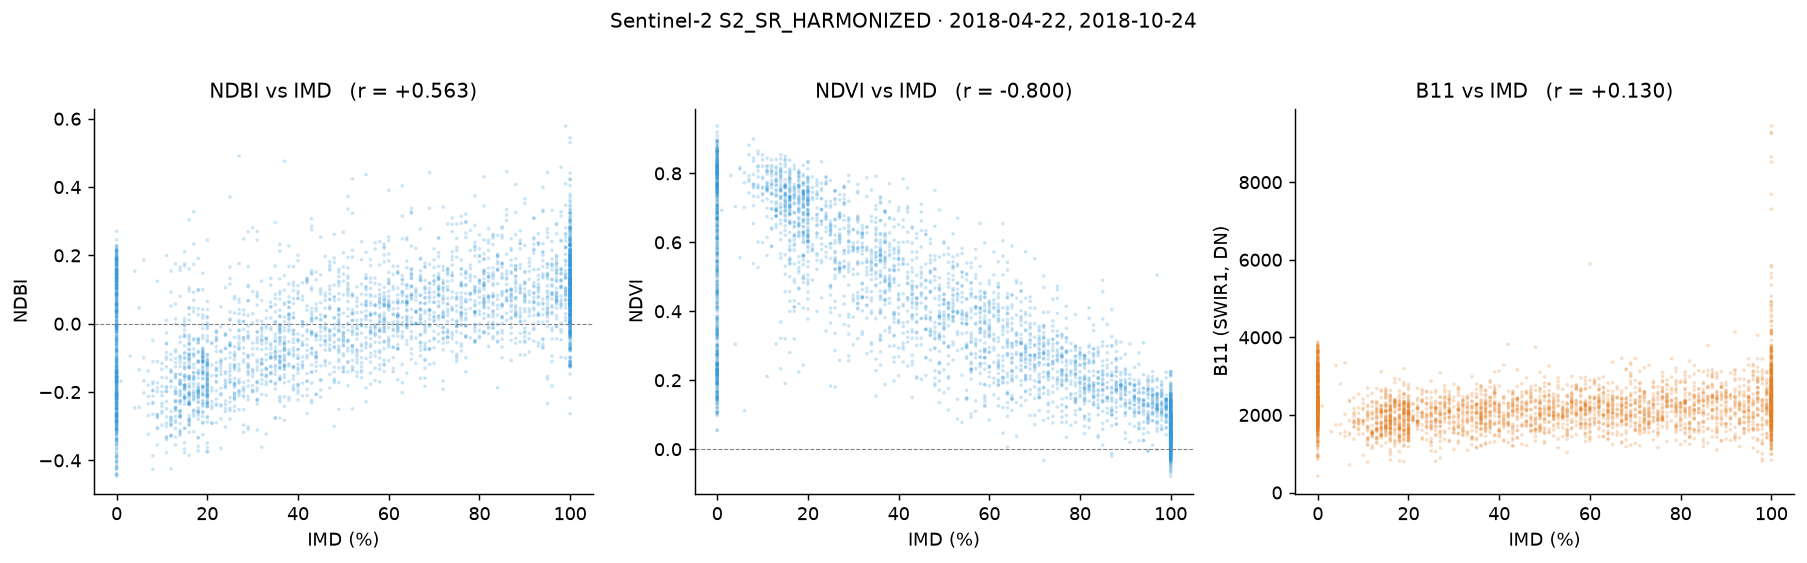

Expect NDBI to rise and NDVI to fall with IMD. A near-zero correlation for both suggests cloud contamination -- revisit the date selection.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# B11/B8/B4 do not exist verbatim under 'percentile' or 'stack' -- map each to
# that method's central representative (p50, or the first date).
_suffix = {'median': '', 'percentile': '_p50', 'stack': '_d00'}[COMPOSITE_METHOD]
B = {b: f'{b}{_suffix}' for b in ('B4', 'B8', 'B11')}
print(f'Inspecting: {list(B.values())}')

ndbi = ((gdf_out[B['B11']] - gdf_out[B['B8']]) /
        (gdf_out[B['B11']] + gdf_out[B['B8']])).values
ndvi = ((gdf_out[B['B8']]  - gdf_out[B['B4']]) /
        (gdf_out[B['B8']]  + gdf_out[B['B4']])).values
imd  = gdf_out['IMD'].values

for ax, (v, name) in zip(axes[:2], [(ndbi, 'NDBI'), (ndvi, 'NDVI')]):
    ax.scatter(imd, v, s=4, alpha=.25, c='#3498db', edgecolors='none')
    r = np.corrcoef(imd, v)[0, 1]
    ax.set_xlabel('IMD (%)'); ax.set_ylabel(name)
    ax.set_title(f'{name} vs IMD   (r = {r:+.3f})')
    ax.axhline(0, lw=.6, c='grey', ls='--')

_b11 = gdf_out[B['B11']].values
axes[2].scatter(imd, _b11, s=4, alpha=.25, c='#e67e22', edgecolors='none')
axes[2].set_xlabel('IMD (%)'); axes[2].set_ylabel(f"{B['B11']} (SWIR1, DN)")
axes[2].set_title(f"{B['B11']} vs IMD   (r = {np.corrcoef(imd, _b11)[0,1]:+.3f})")

_dates_lbl = (', '.join(SELECTED_DATES) if len(SELECTED_DATES) <= 4
              else f'{len(SELECTED_DATES)} dates, {SELECTED_DATES[0]} .. {SELECTED_DATES[-1]}')
plt.suptitle(f'Sentinel-2 {S2_COLLECTION.split("/")[-1]} · {COMPOSITE_METHOD} · {_dates_lbl}',
             y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

print('Expect NDBI to rise and NDVI to fall with IMD. A near-zero correlation '
      'for both suggests cloud contamination -- revisit the date selection.')